<a href="https://colab.research.google.com/github/Eshachatterjee01/data_science_all/blob/main/Gradient_Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error,r2_score

Create Sample Data

In [ ]:
data = {
    'IQ': [90, 100, 110, 120, 130, 140, 150, 160],
    'CGPA': [6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5],
    'Salary': [3.0, 3.5, 4.0, 5.0, 5.5, 6.0, 6.8, 7.5]  # in LPA
}

In [ ]:
df = pd.DataFrame(data)
df

,IQ,CGPA,Salary
0,90,6.0,3.0
1,100,6.5,3.5
2,110,7.0,4.0
3,120,7.5,5.0
4,130,8.0,5.5
5,140,8.5,6.0
6,150,9.0,6.8
7,160,9.5,7.5


Split into Train and Test Sets

In [ ]:
x = df[['IQ','CGPA']]
y=df['Salary']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state=42)

Train Gradient Boosting Regressor

In [ ]:
gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [ ]:
gbr.fit(x_train,y_train)

GradientBoostingRegressor(random_state=42)

Make Predictions

In [ ]:
y_pred = gbr.predict(x_test)

In [ ]:
y_pred #array

array([3.00006109, 5.49999469])

In [ ]:
y_test #dataframe

,Salary
1,3.5
5,6.0


In [ ]:
result = pd.DataFrame({'Actual': y_test.values, 'Predicted' : y_pred})
result

,Actual,Predicted
0,3.5,3.000061
1,6.0,5.499995


In [ ]:
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

In [ ]:
print(f"Mean Squared Error:{mse:.3f}")
print(f"R2 Score:{r2:.3f}")

Mean Squared Error:0.250
R2 Score:0.840


Visualize Results

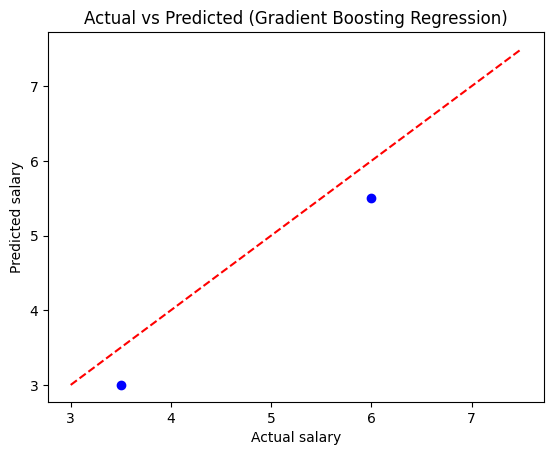

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test,y_pred,color='blue')
plt.plot([y.min(),y.max()],[y.min(),y.max()],'r--')
plt.xlabel('Actual salary')
plt.ylabel('Predicted salary')
plt.title('Actual vs Predicted (Gradient Boosting Regression)')
plt.show()